# Phishing Websites from UCI 

## Logistic Regression

### 1. Import Libraries

In [1]:
from sklearn.linear_model import LogisticRegression
from ucimlrepo import fetch_ucirepo
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,f1_score,recall_score,auc, roc_curve,ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import tracemalloc 
import time

### 2. Load Dataset

In [2]:
phishing=fetch_ucirepo(id=327)
x=phishing.data.features
y=phishing.data.targets.values.ravel()
print(f"Dataset loaded: {x.shape[0]} samples, {x.shape[1]} features")

Dataset loaded: 11055 samples, 30 features


### 3. Train-Test Split

In [3]:
x_trn,x_tst,y_trn,y_tst = train_test_split(x,y,test_size=0.3,random_state=42)

### 4. Preprocessing — StandardScaler

In [4]:
scaler=joblib.load("scaler1.pkl")
x_trn=scaler.transform(x_trn)
x_tst=scaler.transform(x_tst)

### 5. Train Model — Logistic Regression

In [5]:
logr=LogisticRegression(max_iter=1000)

In [6]:
logr.fit(x_trn,y_trn)
start = time.time()
y_pred=logr.predict(x_tst)
time1=time.time() - start
print("Logistic Prediction time:", time1)

Logistic Prediction time: 0.00147247314453125


In [7]:
tracemalloc.start()
_ = logr.predict(x_tst)
current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f"Memory Usage (current): {current_mem / 1024:.2f} KB")
print(f"Memory Usage (peak):    {peak_mem / 1024:.2f} KB")

Memory Usage (current): 27.66 KB
Memory Usage (peak):    79.87 KB


In [8]:
joblib.dump(logr,"logrModel.pkl")

['logrModel.pkl']

### 6. Overfitting Check

In [9]:
train_accuracy = logr.score(x_trn, y_trn)
test_accuracy  = accuracy_score(y_tst, y_pred)

print(f"Training Accuracy : {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy     : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"Difference        : {abs(train_accuracy - test_accuracy):.4f}")

if abs(train_accuracy - test_accuracy) < 0.02:
    print("Status            : No Overfitting (difference < 2%)")
elif abs(train_accuracy - test_accuracy) < 0.05:
    print("Status            : Slight Overfitting (difference 2-5%)")
else:
    print("Status            : Overfitting detected (difference > 5%)")

Training Accuracy : 0.9314 (93.14%)
Test Accuracy     : 0.9219  (92.19%)
Difference        : 0.0095
Status            : No Overfitting (difference < 2%)


### 7. EVALUATION METRICS

In [10]:
accuuracy = accuracy_score(y_tst,y_pred)
precision=precision_score(y_tst,y_pred)
recall    = recall_score(y_tst, y_pred)
f1score=f1_score(y_tst,y_pred)
confusionMatrix=confusion_matrix(y_tst,y_pred)

In [11]:
print("Accuracy = ",accuuracy)
print("Precision = ",precision)
print(f"Recall    = {recall:.4f}  ({recall*100:.2f}%)")
print("F1 Score = ",f1score)
print(f"Prediction Time : {time1:.6f} sec")
print(f"Peak Memory     : {peak_mem / 1024:.2f} KB")

Accuracy =  0.9219173952366596
Precision =  0.9312169312169312
Recall    = 0.9317  (93.17%)
F1 Score =  0.931463350092617
Prediction Time : 0.001472 sec
Peak Memory     : 79.87 KB


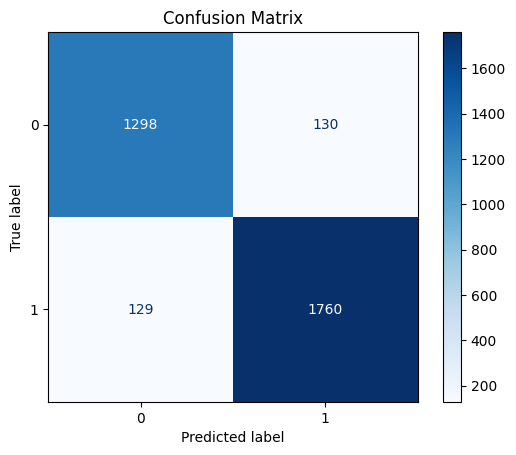

In [12]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusionMatrix)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [13]:
print("Confusion Matrix : \n",confusionMatrix)

Confusion Matrix : 
 [[1298  130]
 [ 129 1760]]


In [14]:
y_prob = logr.predict_proba(x_tst)[:,1]
fpr, tpr, _ = roc_curve(y_tst, y_prob)
roc_auc = auc(fpr, tpr)
print(f"\nROC-AUC Score = {roc_auc:.4f}")


ROC-AUC Score = 0.9777


### 8. ROC CURVE + AUC

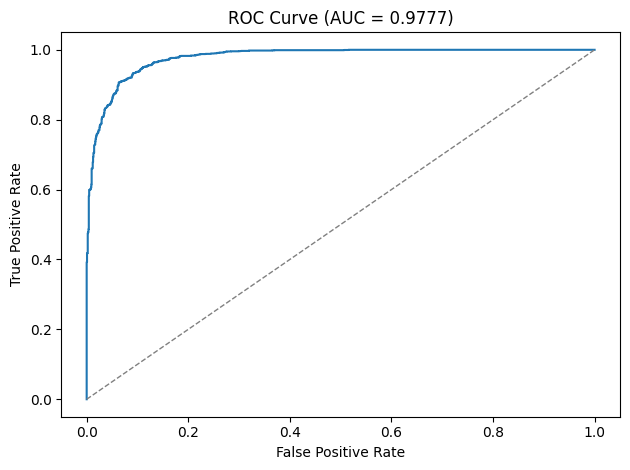

In [15]:
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = %0.4f)" % roc_auc)
plt.tight_layout()
plt.savefig("roc_logistic_regression.png", dpi=150)
plt.show()


### 9. Summary Table

In [16]:
summary = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy (%)":  [round(accuuracy * 100, 2)],
    "Precision (%)": [round(precision * 100, 2)],
    "Recall (%)":    [round(recall * 100, 2)],
    "F1-Score (%)":  [round(f1score * 100, 2)],
    "ROC-AUC":       [round(roc_auc, 4)],
    "Pred Time (s)": [round(time1, 6)],
    "Peak Mem (KB)": [round(peak_mem / 1024, 2)]
})

print(summary.to_string(index=False))


              Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  ROC-AUC  Pred Time (s)  Peak Mem (KB)
Logistic Regression         92.19          93.12       93.17         93.15   0.9777       0.001472          79.87
